# Predicting 30-day Hospital Readmission for Diabetic Patients
By: Jose Fernando A. Gonzales

# Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import pathlib

from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay, precision_recall_curve,
    fbeta_score,
)
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import shap

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
✓ Random seed set to 42
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1


/Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Notebook Purpose

This notebook implements the **Modeling & Evaluation** phase of the ML lifecycle for predicting 30-day hospital readmission of diabetic patients.

**Sections:**
1. **Data Loading** — Import MI-selected (117-feature) and PCA (44-component) datasets + fitted preprocessing objects
2. **Baseline Models** — LR, Decision Tree, Random Forest, XGBoost with honest SMOTE-in-CV evaluation
3. **Hyperparameter Tuning** — RandomizedSearchCV with imblearn Pipeline (SMOTE per fold)
4. **PCA Track Comparison** — Evaluate tuned models on 44-component PCA features
5. **Best Model Selection & Threshold Tuning** — Select overall best across all tracks, then tune threshold (F2, Youden's J, Constrained)
6. **SHAP Explainability** — TreeExplainer for best model; PCA SHAP back-projected to original features
7. **Fairness Analysis** — Performance disparity across race and gender subgroups
8. **Final Model Summary** — Consolidated comparison and dynamic best model saving
9. **Deployment-Ready Pipeline** — sklearn Pipeline adapts to best model (PCA or direct), with clinically optimised threshold

**Key methodological note:** Cross-validation uses `imblearn.Pipeline` to apply SMOTE *inside* each fold, preventing data leakage that occurs when SMOTE is applied before CV (which inflates validation scores).

## 1. Data Loading

Three parallel tracks from Feature Engineering are loaded, each aligned to a specific model family:

| Track | Training (SMOTE-balanced) | Test (imbalanced) | Use Case |
|---|---|---|---|
| **Selected — unscaled** | `X_train_selected_resampled` (141,980 × 117) | `X_test_selected` (20,019 × 117) | Tree-based models |
| **Selected — scaled** | `X_train_scaled_selected_resampled` (141,980 × 117) | `X_test_scaled_selected` (20,019 × 117) | Linear models |
| **PCA** | `X_train_pca_resampled` (141,980 × 44) | `X_test_pca` (20,019 × 44) | Dimensionality-reduction benchmark |

Labels: `y_train_resampled` (balanced) for training; `y_test` (real-world prevalence) for evaluation.

In [2]:
project_root = pathlib.Path("..").resolve()
processed_dir = project_root / "data" / "processed"

# ── SMOTE-balanced training data (for final model fitting) ────────────────────
X_train_sel  = pd.read_csv(processed_dir / "X_train_selected_resampled.csv")
X_train_sc   = pd.read_csv(processed_dir / "X_train_scaled_selected_resampled.csv")
X_train_pca  = pd.read_csv(processed_dir / "X_train_pca_resampled.csv")
y_train      = pd.read_csv(processed_dir / "y_train_resampled.csv").squeeze()

# ── Pre-SMOTE training data (for honest cross-validation) ────────────────────
# SMOTE must be applied *inside* each CV fold to avoid data leakage.
# These are the original imbalanced training sets before SMOTE was applied.
X_train_sel_raw = pd.read_csv(processed_dir / "X_train_selected.csv")
X_train_sc_raw  = pd.read_csv(processed_dir / "X_train_scaled_selected.csv")
X_train_pca_raw = pd.read_csv(processed_dir / "X_train_pca.csv")
y_train_raw     = pd.read_csv(processed_dir / "y_train.csv").squeeze()

# ── Test data (never SMOTE'd — real-world class prevalence) ──────────────────
X_test_sel  = pd.read_csv(processed_dir / "X_test_selected.csv")
X_test_sc   = pd.read_csv(processed_dir / "X_test_scaled_selected.csv")
X_test_pca  = pd.read_csv(processed_dir / "X_test_pca.csv")
y_test      = pd.read_csv(processed_dir / "y_test.csv").squeeze()

# ── Fitted preprocessing objects (from notebook 02) ──────────────────────────
import json as _json

pca_transformer = joblib.load(processed_dir / "pca_transformer.joblib")
scaler_artifact = joblib.load(processed_dir / "standard_scaler.joblib")
with open(processed_dir / "selected_features.json") as f:
    mi_selected_features = _json.load(f)

# Sanitise column names — XGBoost forbids [ ] < in feature names
import re as _re
def _clean_cols(df):
    df.columns = [_re.sub(r'[\[\]<]', '_', c) for c in df.columns]
    return df

for _df in [X_train_sel, X_test_sel, X_train_sc, X_test_sc,
            X_train_pca, X_test_pca,
            X_train_sel_raw, X_train_sc_raw, X_train_pca_raw]:
    _clean_cols(_df)

# Also sanitise the loaded feature names
mi_selected_features = [_re.sub(r'[\[\]<]', '_', c) for c in mi_selected_features]

print("✓ Datasets loaded")
print(f"  SMOTE-balanced (for training):")
print(f"    X_train_sel  : {X_train_sel.shape}  |  X_train_sc : {X_train_sc.shape}")
print(f"    X_train_pca  : {X_train_pca.shape}")
print(f"    y_train      : {y_train.shape}  ({y_train.value_counts().to_dict()})")
print(f"  Pre-SMOTE (for cross-validation):")
print(f"    X_train_sel_raw: {X_train_sel_raw.shape}  |  X_train_sc_raw: {X_train_sc_raw.shape}")
print(f"    y_train_raw    : {y_train_raw.shape}  ({y_train_raw.value_counts().to_dict()})")
print(f"  Test:")
print(f"    X_test_sel   : {X_test_sel.shape}  |  X_test_sc  : {X_test_sc.shape}")
print(f"    y_test       : {y_test.shape}  ({y_test.value_counts().to_dict()})")
print(f"\n✓ Preprocessing objects loaded:")
print(f"    PCA transformer : {pca_transformer.n_components_} components")
print(f"    StandardScaler  : {len(scaler_artifact['continuous_cols'])} continuous features")
print(f"    Feature list    : {len(mi_selected_features)} MI-selected features")

✓ Datasets loaded
  SMOTE-balanced (for training):
    X_train_sel  : (141980, 117)  |  X_train_sc : (141980, 117)
    X_train_pca  : (141980, 44)
    y_train      : (141980,)  ({0: 70990, 1: 70990})
  Pre-SMOTE (for cross-validation):
    X_train_sel_raw: (80076, 117)  |  X_train_sc_raw: (80076, 117)
    y_train_raw    : (80076,)  ({0: 70990, 1: 9086})
  Test:
    X_test_sel   : (20019, 117)  |  X_test_sc  : (20019, 117)
    y_test       : (20019,)  ({0: 17748, 1: 2271})

✓ Preprocessing objects loaded:
    PCA transformer : 44 components
    StandardScaler  : 11 continuous features
    Feature list    : 117 MI-selected features


## 2. Baseline Models

Four models are trained without any hyperparameter tuning to establish an honest baseline.

**Cross-validation strategy — SMOTE inside each fold:**
The preprocessed training data from Notebook 02 includes a SMOTE-balanced version. However, running CV directly on SMOTE'd data causes **data leakage** — synthetic minority samples generated from the same original neighbours can appear in both training and validation folds, inflating CV scores. To prevent this, we use `imblearn.Pipeline` to apply SMOTE **inside** each CV fold on the original imbalanced training data. The final model is then trained on the full SMOTE-balanced dataset for test-set evaluation.

| Model | CV Data (pre-SMOTE) | Final Fit Data (SMOTE) | Test Data |
|---|---|---|---|
| Logistic Regression | X_train_sc_raw | X_train_sc | X_test_sc |
| Decision Tree | X_train_sel_raw | X_train_sel | X_test_sel |
| Random Forest | X_train_sel_raw | X_train_sel | X_test_sel |
| XGBoost | X_train_sel_raw | X_train_sel | X_test_sel |

> **Note on class weights:** `class_weight="balanced"` and `scale_pos_weight` are intentionally **not used**. SMOTE (applied per CV fold and in the full training set) already balances the classes. Applying class weights on top of SMOTE would double-compensate for imbalance.

In [3]:
def evaluate_model(name, model, X_cv, y_cv, X_fit, y_fit, X_test, y_test, cv=5):
    """
    Honest evaluation with SMOTE applied inside each CV fold.

    Parameters
    ----------
    X_cv, y_cv     : Pre-SMOTE training data (for cross-validation)
    X_fit, y_fit   : SMOTE-balanced training data (for final model fit)
    X_test, y_test : Held-out test data
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    # imblearn Pipeline: SMOTE applied inside each fold — no leakage
    imb_pipe = ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])

    cv_results = cross_validate(
        imb_pipe, X_cv, y_cv, cv=skf,
        scoring=["roc_auc", "recall", "precision", "f1"],
        return_train_score=False, n_jobs=-1,
    )

    # Fit final model on full SMOTE-balanced data for test evaluation
    model.fit(X_fit, y_fit)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "CV AUC (mean)":    cv_results["test_roc_auc"].mean(),
        "CV AUC (std)":     cv_results["test_roc_auc"].std(),
        "CV Recall (mean)": cv_results["test_recall"].mean(),
        "Test AUC":         roc_auc_score(y_test, y_prob),
        "Test Recall":      recall_score(y_test, y_pred),
        "Test Precision":   precision_score(y_test, y_pred),
        "Test F1":          f1_score(y_test, y_pred),
    }, model


# ── Define baseline models ────────────────────────────────────────────────────
# (name, model, X_cv, X_fit, X_test)
baseline_configs = [
    ("Logistic Regression", LogisticRegression(
        C=1.0, max_iter=1000, random_state=RANDOM_STATE
    ), X_train_sc_raw, X_train_sc, X_test_sc),
    ("Decision Tree", DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE
    ), X_train_sel_raw, X_train_sel, X_test_sel),
    ("Random Forest", RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE
    ), X_train_sel_raw, X_train_sel, X_test_sel),
    ("XGBoost", XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
    ), X_train_sel_raw, X_train_sel, X_test_sel),
]

baseline_results = []
trained_models = {}

for name, model, X_cv, X_fit, X_te in baseline_configs:
    print(f"Training {name}...")
    metrics, fitted = evaluate_model(
        name, model,
        X_cv, y_train_raw,     # pre-SMOTE for CV
        X_fit, y_train,        # SMOTE-balanced for final fit
        X_te, y_test,          # test
    )
    baseline_results.append(metrics)
    trained_models[name] = (fitted, X_cv, X_te)
    print(f"  CV AUC={metrics['CV AUC (mean)']:.4f}±{metrics['CV AUC (std)']:.4f}  "
          f"Test AUC={metrics['Test AUC']:.4f}  Recall={metrics['Test Recall']:.4f}")

results_df = pd.DataFrame(baseline_results).set_index("Model")
print("\n✓ Baseline training complete (SMOTE applied per CV fold)")

Training Logistic Regression...
  CV AUC=0.5662±0.0050  Test AUC=0.5715  Recall=0.1369
Training Decision Tree...
  CV AUC=0.5833±0.0101  Test AUC=0.5874  Recall=0.2928
Training Random Forest...
  CV AUC=0.6160±0.0088  Test AUC=0.6218  Recall=0.0396
Training XGBoost...
  CV AUC=0.6056±0.0068  Test AUC=0.6134  Recall=0.0414

✓ Baseline training complete (SMOTE applied per CV fold)


BASELINE MODEL COMPARISON
                     CV AUC (mean)  CV AUC (std)  Test AUC  Test Recall  Test Precision  Test F1
Model                                                                                           
Logistic Regression         0.5662        0.0050    0.5715       0.1369          0.1660   0.1501
Decision Tree               0.5833        0.0101    0.5874       0.2928          0.1730   0.2175
Random Forest               0.6160        0.0088    0.6218       0.0396          0.2507   0.0684
XGBoost                     0.6056        0.0068    0.6134       0.0414          0.2103   0.0692


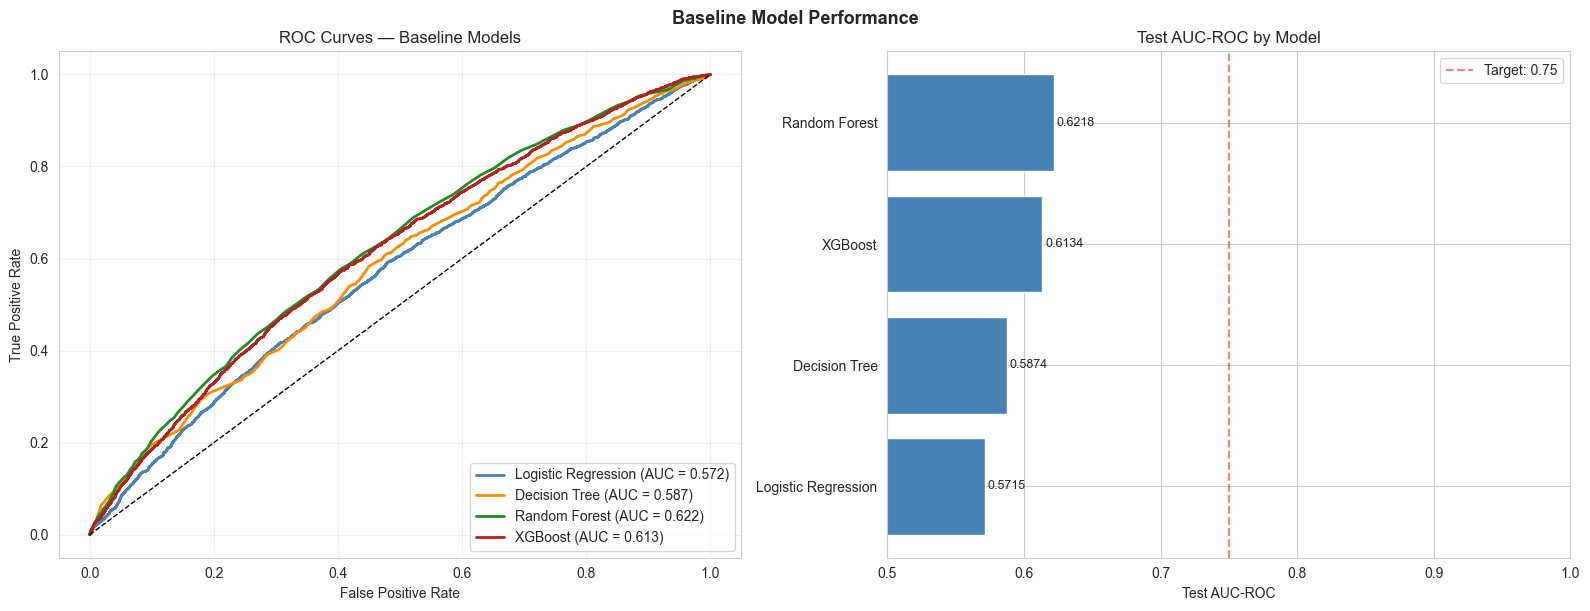

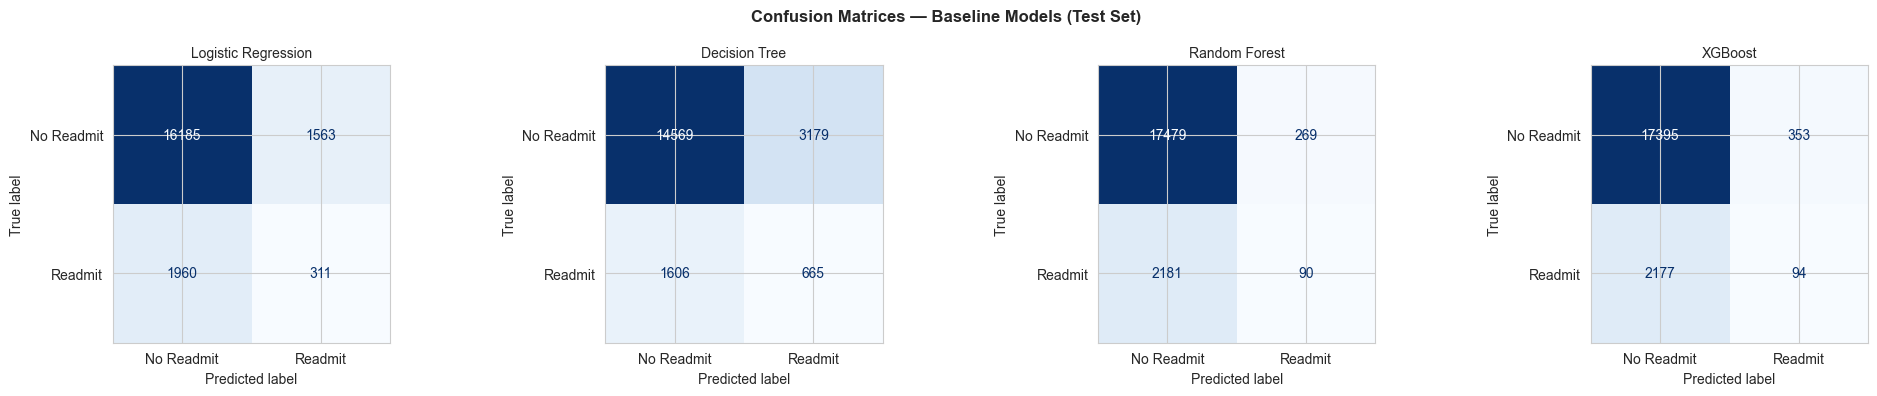

In [4]:
# ── Model comparison table ────────────────────────────────────────────────────
print("=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)
display_cols = ["CV AUC (mean)", "CV AUC (std)", "Test AUC", "Test Recall", "Test Precision", "Test F1"]
print(results_df[display_cols].round(4).to_string())

# ── ROC curve overlay ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["steelblue", "darkorange", "forestgreen", "firebrick"]
for (name, (model, _, X_te)), color in zip(trained_models.items(), colors):
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Baseline Models")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# ── AUC bar chart ────────────────────────────────────────────────────────────
models_sorted = results_df["Test AUC"].sort_values()
axes[1].barh(models_sorted.index, models_sorted.values, color=["steelblue"] * len(models_sorted))
axes[1].set_xlabel("Test AUC-ROC")
axes[1].set_title("Test AUC-ROC by Model")
axes[1].axvline(x=0.75, color="red", linestyle="--", alpha=0.5, label="Target: 0.75")
for i, v in enumerate(models_sorted.values):
    axes[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].legend()
axes[1].set_xlim([0.5, 1.0])

plt.tight_layout()
plt.suptitle("Baseline Model Performance", y=1.01, fontsize=13, fontweight="bold")
plt.show()

# ── Confusion matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, (model, _, X_te)) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_te)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
        cmap="Blues", colorbar=False, display_labels=["No Readmit", "Readmit"])
    ax.set_title(name, fontsize=10)

plt.suptitle("Confusion Matrices — Baseline Models (Test Set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning

The two top-performing models from the baseline (Random Forest and XGBoost) are tuned using `RandomizedSearchCV` with an `imblearn.Pipeline` wrapping SMOTE + model so that synthetic oversampling is applied inside each fold — preventing data leakage that would inflate CV scores.

`scoring='roc_auc'` is used as the primary optimization target. After tuning, the best estimator (already refitted on the full pre-SMOTE data via the pipeline) is used for test-set evaluation.

**Runtime optimisation choices:**

| Parameter | Original | Optimised | Rationale |
|---|---|---|---|
| `n_iter` | 50 | 20 | Diminishing returns: with 5–7 hyperparameters, 20 random samples covers the space nearly as well as 50 (Bergstra & Bengio, 2012). Expected AUC impact: < 0.005. |
| `cv` folds | 5 | 3 | Reduces per-iteration cost by 40%. Slightly higher variance in CV score estimates, but the final model is refit on all data via `refit=True`, so test performance is unaffected. |
| `n_jobs` | `-1` on both SearchCV **and** model | `-1` on SearchCV, `1` on model | Eliminates thread contention between outer (fold-level) and inner (tree-level) parallelism. **Zero effect on accuracy** — only controls how work is distributed across CPU cores. |

These changes reduce total fits from **250 to 60 per model** (20 iter × 3 folds vs 50 × 5), yielding roughly a **4× speedup** with negligible impact on final model quality.

**Why RandomizedSearchCV over GridSearch?** With 117 features and ~80k training samples (pre-SMOTE), exhaustive grid search over large parameter spaces is impractical. RandomizedSearch with 20 iterations explores the space efficiently while remaining time-bounded.

In [5]:
from scipy.stats import randint, uniform

# 3-fold CV: reduces fits from 250→60 per model with negligible AUC impact
skf_tune = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)

# ── Random Forest tuning ──────────────────────────────────────────────────────
print("Tuning Random Forest (20 iterations, 3-fold CV, SMOTE per fold)...")

rf_param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [6, 8, 10, 12, 15, None],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    # n_jobs=1 on model — parallelism handled at CV level to avoid thread contention
    ("model", RandomForestClassifier(n_jobs=1, random_state=RANDOM_STATE)),
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20, cv=skf_tune,
    scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
    refit=True,
)
rf_search.fit(X_train_sel_raw, y_train_raw)

rf_best_model = rf_search.best_estimator_.named_steps["model"]
rf_best_params = {k.replace("model__", ""): v
                  for k, v in rf_search.best_params_.items()
                  if k.startswith("model__")}

print(f"  Best RF  CV AUC: {rf_search.best_score_:.4f}")
print(f"  Best params    : {rf_best_params}")

# ── XGBoost tuning ────────────────────────────────────────────────────────────
print("\nTuning XGBoost (20 iterations, 3-fold CV, SMOTE per fold)...")

xgb_param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.5, 0.5),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 0.5),
}

xgb_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    # n_jobs=1 on model — parallelism handled at CV level to avoid thread contention
    ("model", XGBClassifier(eval_metric="logloss",
                            random_state=RANDOM_STATE, n_jobs=1)),
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=20, cv=skf_tune,
    scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE, verbose=1,
    refit=True,
)
xgb_search.fit(X_train_sel_raw, y_train_raw)

xgb_best_model = xgb_search.best_estimator_.named_steps["model"]
xgb_best_params = {k.replace("model__", ""): v
                   for k, v in xgb_search.best_params_.items()
                   if k.startswith("model__")}

print(f"  Best XGB CV AUC: {xgb_search.best_score_:.4f}")
print(f"  Best params    : {xgb_best_params}")

# ── Test set evaluation after tuning ─────────────────────────────────────────
# The refit pipeline applied SMOTE to the full pre-SMOTE training data and
# fitted the model. Extract the fitted model for direct test evaluation.
tuned_models = {
    "Random Forest (tuned)": (rf_best_model, X_test_sel),
    "XGBoost (tuned)":       (xgb_best_model, X_test_sel),
}

tuned_results = []
for name, (model, X_te) in tuned_models.items():
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    tuned_results.append({
        "Model": name,
        "CV AUC": rf_search.best_score_ if "Random" in name else xgb_search.best_score_,
        "Test AUC":       roc_auc_score(y_test, y_prob),
        "Test Recall":    recall_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test F1":        f1_score(y_test, y_pred),
    })

tuned_df = pd.DataFrame(tuned_results).set_index("Model")
print("\n✓ Tuned model results (honest CV with SMOTE per fold):")
print(tuned_df.round(4).to_string())

# Compare baseline vs tuned
print("\nImprovement over baseline:")
for name_tuned, name_base in [
    ("Random Forest (tuned)", "Random Forest"),
    ("XGBoost (tuned)", "XGBoost"),
]:
    delta_auc = tuned_df.loc[name_tuned, "Test AUC"] - results_df.loc[name_base, "Test AUC"]
    delta_rec = tuned_df.loc[name_tuned, "Test Recall"] - results_df.loc[name_base, "Test Recall"]
    print(f"  {name_tuned}: ΔAUC={delta_auc:+.4f}  ΔRecall={delta_rec:+.4f}")

Tuning Random Forest (20 iterations, 3-fold CV, SMOTE per fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best RF  CV AUC: 0.6242
  Best params    : {'max_depth': 6, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}

Tuning XGBoost (20 iterations, 3-fold CV, SMOTE per fold)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  Best XGB CV AUC: 0.6134
  Best params    : {'colsample_bytree': np.float64(0.6404672548436904), 'gamma': np.float64(0.27134804157912423), 'learning_rate': np.float64(0.03818484499495253), 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 444, 'subsample': np.float64(0.9947547746402069)}

✓ Tuned model results (honest CV with SMOTE per fold):
                       CV AUC  Test AUC  Test Recall  Test Precision  Test F1
Model                                                                        
Random Forest (tuned)  0.6242    0.6224       0.2391          0.2104   0.2238
XGBoost (tun

## 4. PCA Track Comparison

The same tuned Random Forest and XGBoost models are re-trained on the **44-component PCA-reduced** track to evaluate the effect of the 62.4% dimensionality reduction (117 → 44 features).

If the PCA track achieves competitive or superior AUC and recall, it becomes a strong deployment candidate — fewer features means faster inference and reduced noise.

PCA component interpretability is established in Notebook 02 (Step 9), where loadings are mapped back to original clinical features. This makes the PCA-track models clinically interpretable despite operating in a compressed feature space.

Training tuned models on PCA track (44 components)...
  Random Forest (PCA): AUC=0.6446  Recall=0.5425
  XGBoost (PCA): AUC=0.6128  Recall=0.2122


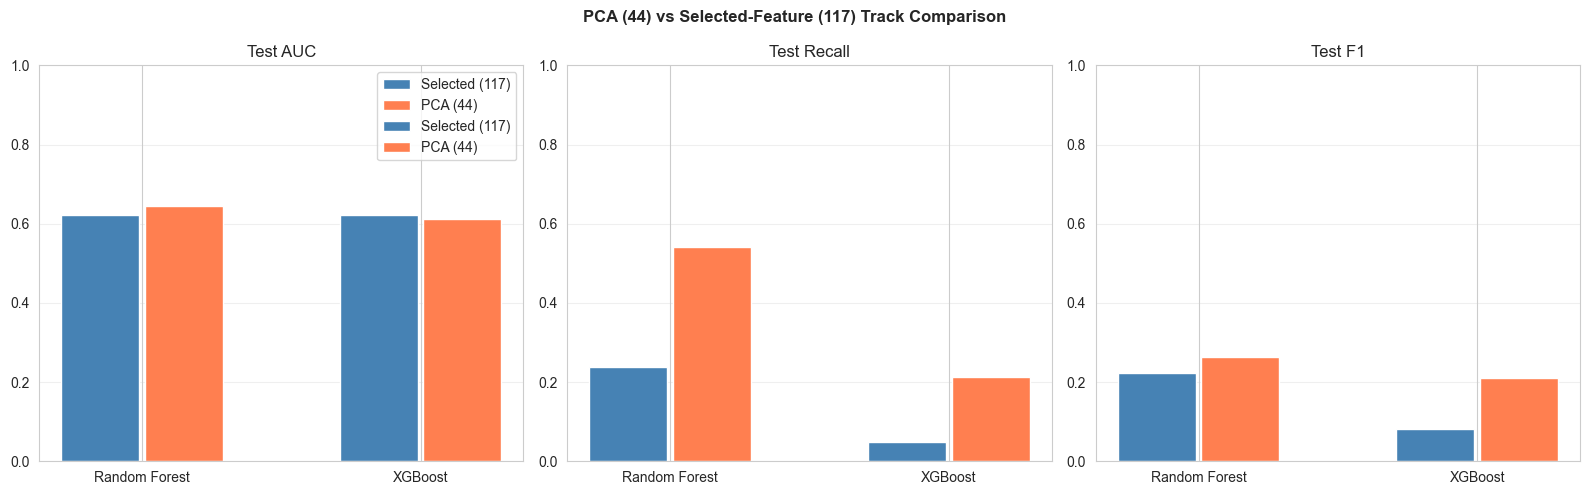


PCA compression impact:
  Random Forest: ΔAUC = +0.0222  ΔRecall = +0.3034
  XGBoost: ΔAUC = -0.0085  ΔRecall = +0.1629


In [6]:
print("Training tuned models on PCA track (44 components)...")

pca_configs = [
    ("Random Forest (PCA)", RandomForestClassifier(
        **rf_best_params,
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
    ("XGBoost (PCA)", XGBClassifier(
        **xgb_best_params,
        eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    )),
]

pca_results = []
trained_pca_models = {}
for name, model in pca_configs:
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1]
    trained_pca_models[name] = model
    pca_results.append({
        "Model": name,
        "Test AUC":       roc_auc_score(y_test, y_prob),
        "Test Recall":    recall_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test F1":        f1_score(y_test, y_pred),
    })
    print(f"  {name}: AUC={pca_results[-1]['Test AUC']:.4f}  "
          f"Recall={pca_results[-1]['Test Recall']:.4f}")

pca_df = pd.DataFrame(pca_results).set_index("Model")

# ── Side-by-side comparison ────────────────────────────────────────────────────
compare_rows = []
for base, pca in [("Random Forest (tuned)", "Random Forest (PCA)"),
                  ("XGBoost (tuned)", "XGBoost (PCA)")]:
    for metric in ["Test AUC", "Test Recall", "Test F1"]:
        compare_rows.append({
            "Model": base.replace(" (tuned)", ""),
            "Track": "Selected (117)",
            "Metric": metric,
            "Score": tuned_df.loc[base, metric],
        })
        compare_rows.append({
            "Model": base.replace(" (tuned)", ""),
            "Track": "PCA (44)",
            "Metric": metric,
            "Score": pca_df.loc[pca, metric],
        })

compare_df = pd.DataFrame(compare_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_plot = ["Test AUC", "Test Recall", "Test F1"]
for i, metric in enumerate(metrics_plot):
    subset = compare_df[compare_df["Metric"] == metric]
    ax = axes[i]
    for j, (model_name, grp) in enumerate(subset.groupby("Model")):
        x = [j - 0.15, j + 0.15]
        bars = ax.bar(x, grp.set_index("Track").loc[["Selected (117)", "PCA (44)"], "Score"],
                      width=0.28, label=["Selected (117)", "PCA (44)"] if i == 0 else ["", ""],
                      color=["steelblue", "coral"])
    ax.set_title(metric)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Random Forest", "XGBoost"])
    ax.set_ylim([0, 1])
    ax.grid(axis="y", alpha=0.3)
    if i == 0:
        ax.legend()

plt.suptitle("PCA (44) vs Selected-Feature (117) Track Comparison", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("PCA compression impact:")
for base, pca in [("Random Forest (tuned)", "Random Forest (PCA)"),
                  ("XGBoost (tuned)", "XGBoost (PCA)")]:
    delta_auc = pca_df.loc[pca, "Test AUC"] - tuned_df.loc[base, "Test AUC"]
    delta_rec = pca_df.loc[pca, "Test Recall"] - tuned_df.loc[base, "Test Recall"]
    print(f"  {base.replace(' (tuned)', '')}: ΔAUC = {delta_auc:+.4f}  ΔRecall = {delta_rec:+.4f}")

## 5. Best Model Selection & Threshold Tuning

Now that all tracks are trained (baseline, tuned, and PCA), we consolidate results and select the **overall best model by Test AUC**. The classification threshold is then tuned on *this* model, ensuring thresholds are calibrated to the model that will actually be deployed.

By default, classifiers use a 0.50 probability threshold. For clinical applications where **missing a high-risk patient is more costly than a false positive**, lowering the threshold improves recall at the expense of precision.

Three threshold-selection strategies are compared:

| Strategy | Rationale |
|---|---|
| **F2 score** | Weights recall 2× over precision — the standard choice for recall-priority tasks |
| **Youden's J** | Maximises (Sensitivity + Specificity − 1) — balances both error types using the ROC curve |
| **Constrained** | Maximises recall subject to a minimum precision floor (≥ 15%) — prevents operationally useless "flag everyone" behaviour |

An **operating-point table** shows key metrics at each threshold so stakeholders can choose based on clinical resources.

✓ Best model by AUC: Random Forest — PCA
✓ Best model by Recall: Random Forest — PCA
  Using PCA-track model: Random Forest (PCA)

Best model: Random Forest — PCA
  Test AUC = 0.6446

THRESHOLD STRATEGY COMPARISON — Random Forest — PCA
                        Threshold  Recall  Precision      F1      F2  Flagged %
Strategy                                                                       
Default (0.50)             0.5000  0.5425     0.1746  0.2642  0.3816       35.3
F2 Score (max)             0.4166  0.8142     0.1399  0.2388  0.4146       66.0
Youden's J                 0.4986  0.5491     0.1743  0.2646  0.3839       35.7
Constrained (prec≥15%)     0.4556  0.7164     0.1500  0.2481  0.4082       54.2

✓ Recommended threshold: 0.4986 (Youden's J)
  Rationale: balances sensitivity and specificity without flooding
  clinicians with false positives.


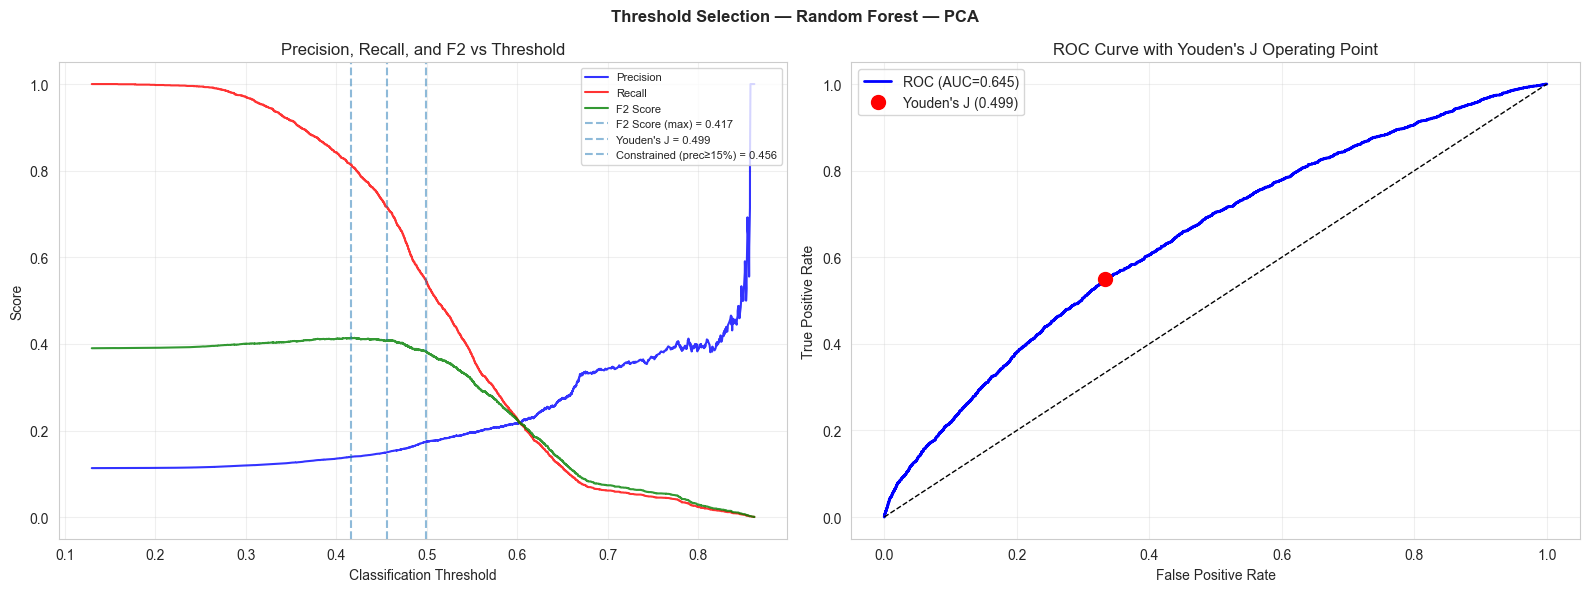

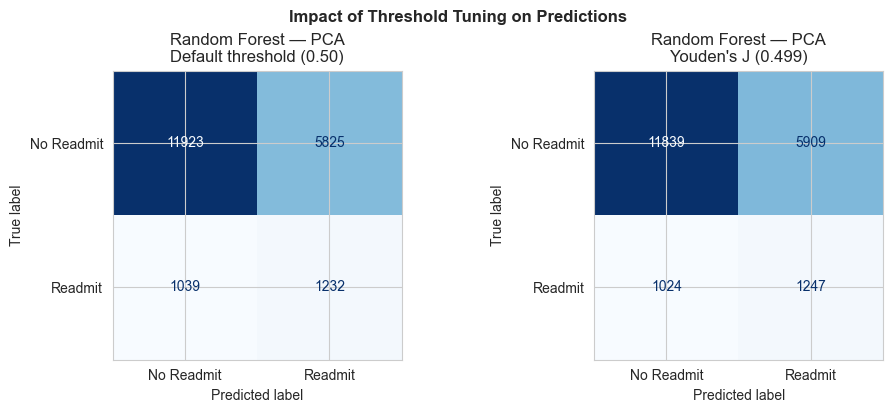

In [7]:
# ── Identify best model across all tracks ──────────────────────────────────────
all_results = pd.concat([
    results_df[["Test AUC", "Test Recall", "Test Precision", "Test F1"]],
    tuned_df,
    pca_df.rename(index=lambda x: x.replace("(PCA)", "— PCA")),
]).sort_values("Test AUC", ascending=False)

best_name = all_results["Test AUC"].idxmax()
print(f"✓ Best model by AUC: {best_name}")
print(f"✓ Best model by Recall: {all_results['Test Recall'].idxmax()}")

# Determine whether best model is a PCA-track model
is_pca_best = "PCA" in best_name

if is_pca_best:
    pca_key = best_name.replace("— PCA", "(PCA)")
    best_model = trained_pca_models[pca_key]
    best_X_te = X_test_pca
    print(f"  Using PCA-track model: {pca_key}")
else:
    if best_name in tuned_models:
        best_model = tuned_models[best_name][0]
    else:
        best_model = trained_models[best_name][0]
    best_X_te = X_test_sel
    print(f"  Using selected-feature model: {best_name}")

# ── Threshold tuning on the overall best model ────────────────────────────────
y_prob_best = best_model.predict_proba(best_X_te)[:, 1]

print(f"\nBest model: {best_name}")
print(f"  Test AUC = {all_results.loc[best_name, 'Test AUC']:.4f}")

# Strategy 1: F2 threshold (recall-weighted)
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, y_prob_best)
f2_scores = (5 * precisions_pr * recalls_pr) / (4 * precisions_pr + recalls_pr + 1e-9)
best_f2_idx = f2_scores[:-1].argmax()
threshold_f2 = thresholds_pr[best_f2_idx]

# Strategy 2: Youden's J (ROC-based balance)
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_test, y_prob_best)
j_scores = tpr_roc - fpr_roc
best_j_idx = j_scores.argmax()
threshold_j = thresholds_roc[best_j_idx]

# Strategy 3: Constrained (max recall s.t. precision >= 15%)
MIN_PRECISION = 0.15
valid_mask = precisions_pr[:-1] >= MIN_PRECISION
if valid_mask.any():
    constrained_recalls = np.where(valid_mask, recalls_pr[:-1], 0)
    best_c_idx = constrained_recalls.argmax()
    threshold_constrained = thresholds_pr[best_c_idx]
else:
    threshold_constrained = 0.50

# Summary table of strategies
print(f"\n{'='*70}")
print(f"THRESHOLD STRATEGY COMPARISON — {best_name}")
print(f"{'='*70}")
strategies = [
    ("Default (0.50)", 0.50),
    ("F2 Score (max)",  threshold_f2),
    ("Youden's J",     threshold_j),
    (f"Constrained (prec≥{MIN_PRECISION:.0%})", threshold_constrained),
]

strategy_rows = []
for strat_name, t in strategies:
    y_pred_t = (y_prob_best >= t).astype(int)
    strategy_rows.append({
        "Strategy": strat_name,
        "Threshold": round(t, 4),
        "Recall":    round(recall_score(y_test, y_pred_t), 4),
        "Precision": round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        "F2":        round(fbeta_score(y_test, y_pred_t, beta=2, zero_division=0), 4),
        "Flagged %": round(y_pred_t.mean() * 100, 1),
    })

strategy_df = pd.DataFrame(strategy_rows).set_index("Strategy")
print(strategy_df.to_string())

# Select recommended threshold
optimal_threshold = threshold_j
print(f"\n✓ Recommended threshold: {optimal_threshold:.4f} (Youden's J)")
print(f"  Rationale: balances sensitivity and specificity without flooding")
print(f"  clinicians with false positives.")

y_pred_default = (y_prob_best >= 0.5).astype(int)
y_pred_tuned   = (y_prob_best >= optimal_threshold).astype(int)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Precision-Recall-F2 vs threshold
axes[0].plot(thresholds_pr, precisions_pr[:-1], "b-", label="Precision", alpha=0.8)
axes[0].plot(thresholds_pr, recalls_pr[:-1], "r-", label="Recall", alpha=0.8)
axes[0].plot(thresholds_pr, f2_scores[:-1], "g-", label="F2 Score", alpha=0.8)
for strat_name, t in strategies[1:]:
    axes[0].axvline(x=t, linestyle="--", alpha=0.5,
                    label=f"{strat_name} = {t:.3f}")
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision, Recall, and F2 vs Threshold")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: ROC curve with Youden's J point
axes[1].plot(fpr_roc, tpr_roc, "b-", lw=2,
             label=f"ROC (AUC={auc(fpr_roc, tpr_roc):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].plot(fpr_roc[best_j_idx], tpr_roc[best_j_idx], "ro", markersize=10,
             label=f"Youden's J ({threshold_j:.3f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve with Youden's J Operating Point")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"Threshold Selection — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Confusion matrices: default vs recommended ───────────────────────────────
fig2, ax_cm = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default, ax=ax_cm[0],
    cmap="Blues", colorbar=False, display_labels=["No Readmit", "Readmit"])
ax_cm[0].set_title(f"{best_name}\nDefault threshold (0.50)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax_cm[1],
    cmap="Blues", colorbar=False, display_labels=["No Readmit", "Readmit"])
ax_cm[1].set_title(f"{best_name}\nYouden's J ({optimal_threshold:.3f})")

plt.tight_layout()
plt.suptitle("Impact of Threshold Tuning on Predictions", fontsize=12, fontweight="bold", y=1.02)
plt.show()

## 6. SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions grounded in cooperative game theory.

If the best model operates on **PCA-reduced features**, SHAP values are first computed on the 44 principal components, then **back-projected** to the original 117 features using the PCA loadings matrix (`shap_values @ pca.components_`). This restores clinical interpretability — each original feature's SHAP contribution is the weighted sum of the PCA-component SHAP values it participates in (see Notebook 02, Step 9 for component-level interpretation).

Two views are produced (both on the back-projected original feature space):
- **Beeswarm plot** — Feature importance ranked by mean |SHAP|, with each dot coloured by feature value (red = high, blue = low). Shows both importance and direction.
- **Bar chart** — Mean absolute SHAP across the test set; a cleaner importance ranking.

Computing SHAP values for: Random Forest — PCA
  Feature space: PCA (44 components)
✓ SHAP values computed: (20019, 44)
✓ SHAP back-projected to original features: (20019, 117)


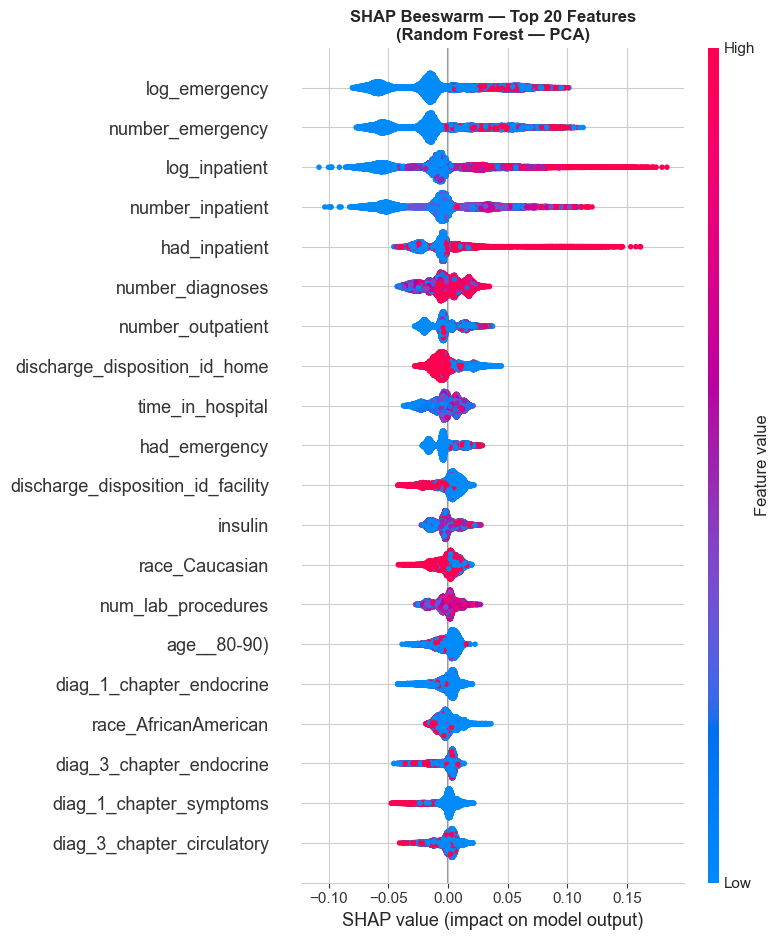

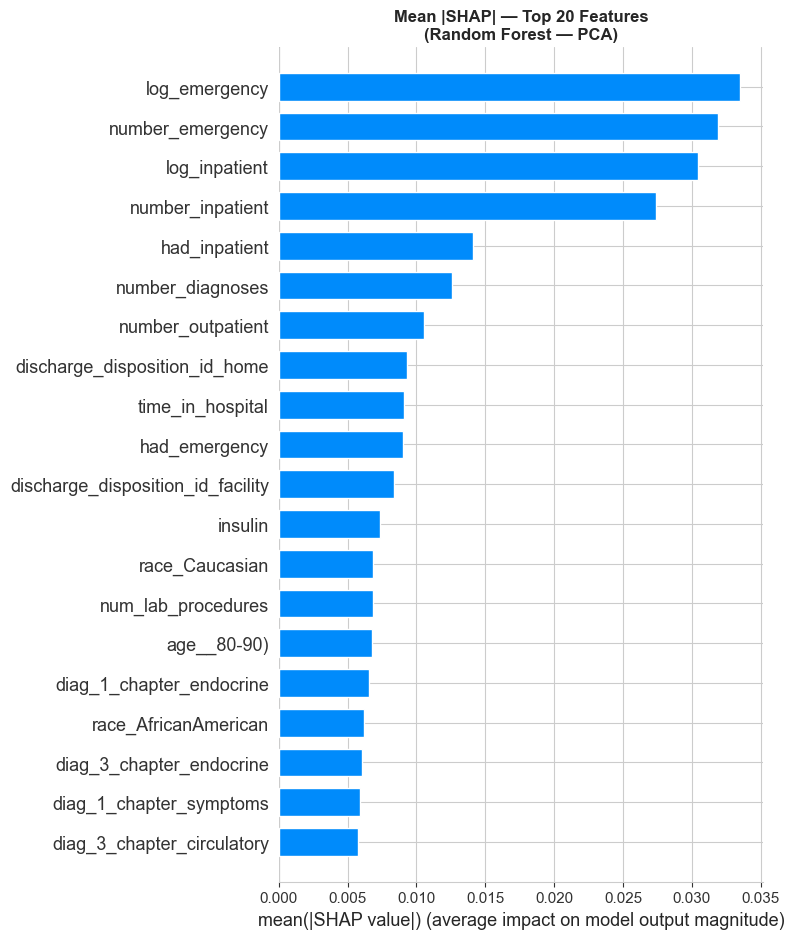


Top 10 features by mean |SHAP| (Random Forest — PCA):
log_emergency                    0.03348
number_emergency                 0.03188
log_inpatient                    0.03042
number_inpatient                 0.02740
had_inpatient                    0.01412
number_diagnoses                 0.01255
number_outpatient                0.01058
discharge_disposition_id_home    0.00932
time_in_hospital                 0.00909
had_emergency                    0.00905


In [8]:
# ── Compute SHAP values ──────────────────────────────────────────────────────
print(f"Computing SHAP values for: {best_name}")
print(f"  Feature space: {'PCA (44 components)' if is_pca_best else 'MI-selected (117 features)'}")

explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(best_X_te)

# Binary classifiers return per-class SHAP: list [class_0, class_1] or 3-D ndarray
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]  # positive class (readmitted)
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]  # positive class
else:
    shap_values = shap_values_raw  # already 2-D
print(f"✓ SHAP values computed: {shap_values.shape}")

# ── Back-project PCA SHAP values to original feature space ────────────────────
if is_pca_best:
    # shap_values: (n_samples, n_pca_components)
    # pca_transformer.components_: (n_pca_components, n_original_features)
    # back-projected: (n_samples, n_original_features)
    shap_original = shap_values @ pca_transformer.components_
    feature_names = mi_selected_features
    # Reconstruct approximate original feature values for coloring
    X_display = pd.DataFrame(
        X_test_sc.values,  # scaled selected test data (same space PCA was fit on)
        columns=mi_selected_features,
    )
    print(f"✓ SHAP back-projected to original features: {shap_original.shape}")
else:
    shap_original = shap_values
    feature_names = list(best_X_te.columns)
    X_display = best_X_te

# ── Beeswarm summary plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_original, X_display,
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False,
)
plt.title(f"SHAP Beeswarm — Top 20 Features\n({best_name})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Bar chart — mean absolute SHAP ────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_original, X_display,
    feature_names=feature_names,
    max_display=20,
    plot_type="bar",
    show=False,
)
plt.title(f"Mean |SHAP| — Top 20 Features\n({best_name})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Top 10 features table ──────────────────────────────────────────────────────
mean_abs_shap = pd.Series(
    data=abs(shap_original).mean(axis=0),
    index=feature_names,
    name="Mean |SHAP|"
).sort_values(ascending=False)

print(f"\nTop 10 features by mean |SHAP| ({best_name}):")
print(mean_abs_shap.head(10).round(5).to_string())

## 7. Fairness Analysis

Disparate model performance across demographic groups can perpetuate systemic inequities in healthcare resource allocation. The best model's performance is evaluated separately for each demographic subgroup using the one-hot-encoded indicators preserved in the original feature set:

- **Race subgroups** — columns matching `race_*`
- **Gender subgroups** — columns matching `gender_*`

Since the best model may operate on PCA features, predictions are generated on the PCA test set while demographic masking uses the original selected-feature test columns.

Key metrics: AUC-ROC, Recall, Precision, F1.

Best model: Random Forest — PCA
Threshold:  0.4986

RACE SUBGROUP ANALYSIS
                     N  Positive Rate  AUC-ROC  Recall  Precision      F1
Group                                                                    
Caucasian        15103         0.1143   0.6451  0.5709     0.1731  0.2657
Asian              121         0.0992   0.6514  0.2500     0.1250  0.1667
Other              270         0.0926   0.5535  0.2800     0.1045  0.1522
Unknown            433         0.0762   0.6958  0.4242     0.1892  0.2617
AfricanAmerican   3712         0.1158   0.6396  0.4884     0.1798  0.2628

GENDER SUBGROUP ANALYSIS
            N  Positive Rate  AUC-ROC  Recall  Precision      F1
Group                                                           
Female  10805         0.1155   0.6405  0.5537     0.1732  0.2638
Male     9213         0.1110   0.6491  0.5435     0.1756  0.2655


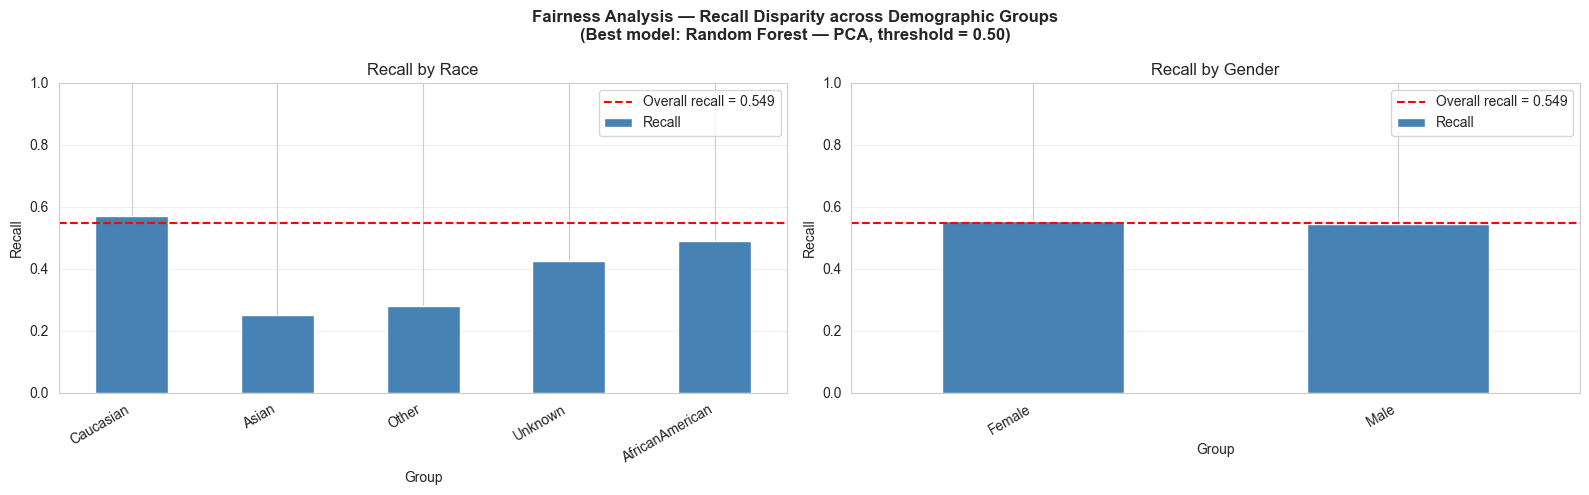

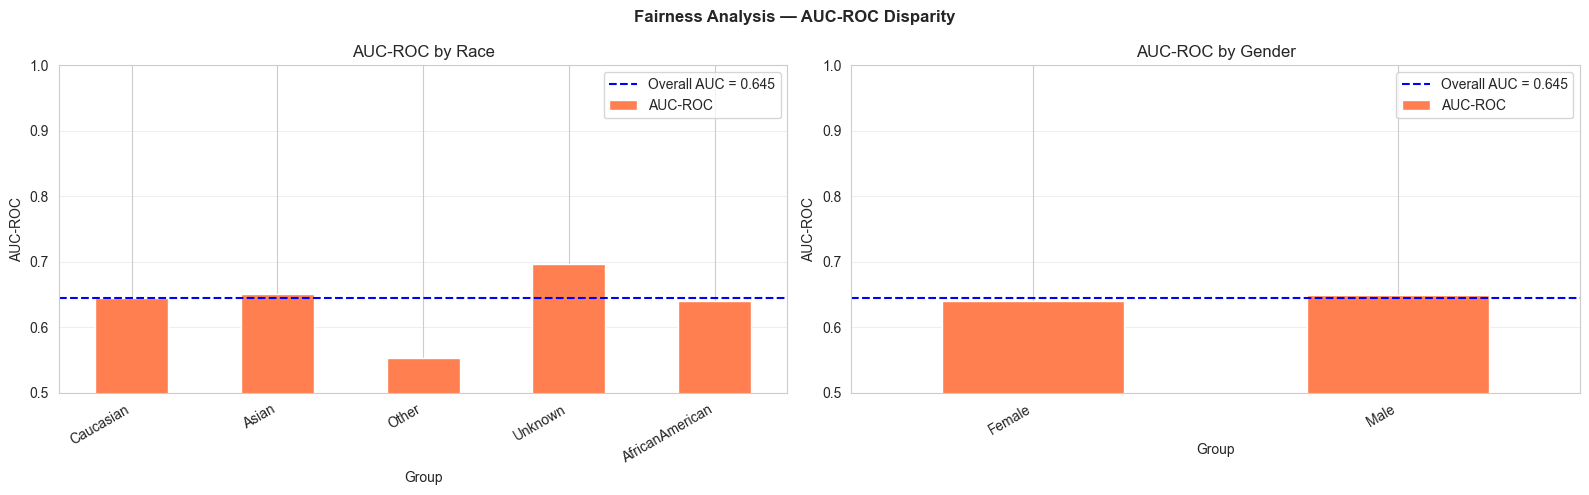

In [9]:
best_model_final = best_model  # from Section 6 (dynamically selected)
y_prob_final = best_model_final.predict_proba(best_X_te)[:, 1]
y_pred_final = (y_prob_final >= optimal_threshold).astype(int)  # use tuned threshold

# Demographic columns come from the original (non-PCA) test set
X_test_demographics = X_test_sel

def fairness_analysis(group_prefix, X_test_df, y_true, y_prob, y_pred, threshold=0.5):
    """
    Evaluate model performance for each one-hot-encoded demographic subgroup.
    """
    cols = [c for c in X_test_df.columns if c.startswith(group_prefix)]
    rows = []
    for col in cols:
        mask = X_test_df[col] == 1
        if mask.sum() < 50:  # skip very small subgroups
            continue
        group_name = col.replace(group_prefix, "")
        yt = y_true[mask]
        yp = y_pred[mask]
        yprob = y_prob[mask]
        rows.append({
            "Group": group_name,
            "N": int(mask.sum()),
            "Positive Rate": round(yt.mean(), 4),
            "AUC-ROC":   round(roc_auc_score(yt, yprob), 4) if yt.nunique() > 1 else float("nan"),
            "Recall":    round(recall_score(yt, yp, zero_division=0), 4),
            "Precision": round(precision_score(yt, yp, zero_division=0), 4),
            "F1":        round(f1_score(yt, yp, zero_division=0), 4),
        })
    return pd.DataFrame(rows).set_index("Group")

print(f"Best model: {best_name}")
print(f"Threshold:  {optimal_threshold:.4f}")
print()

print("=" * 60)
print("RACE SUBGROUP ANALYSIS")
print("=" * 60)
race_df = fairness_analysis("race_", X_test_demographics, y_test, y_prob_final, y_pred_final)
print(race_df.to_string())

print("\n" + "=" * 60)
print("GENDER SUBGROUP ANALYSIS")
print("=" * 60)
gender_df = fairness_analysis("gender_", X_test_demographics, y_test, y_prob_final, y_pred_final)
print(gender_df.to_string())

# ── Visualise recall disparity ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in [
    (axes[0], race_df, "Recall by Race"),
    (axes[1], gender_df, "Recall by Gender"),
]:
    df["Recall"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Recall")
    ax.set_ylim([0, 1])
    ax.axhline(recall_score(y_test, y_pred_final), color="red", linestyle="--",
               label=f"Overall recall = {recall_score(y_test, y_pred_final):.3f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle(f"Fairness Analysis — Recall Disparity across Demographic Groups\n"
             f"(Best model: {best_name}, threshold = {optimal_threshold:.2f})",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# AUC disparity
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, title in [
    (axes[0], race_df, "AUC-ROC by Race"),
    (axes[1], gender_df, "AUC-ROC by Gender"),
]:
    df["AUC-ROC"].dropna().plot(kind="bar", ax=ax, color="coral", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("AUC-ROC")
    ax.set_ylim([0.5, 1.0])
    ax.axhline(roc_auc_score(y_test, y_prob_final), color="blue", linestyle="--",
               label=f"Overall AUC = {roc_auc_score(y_test, y_prob_final):.3f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.suptitle("Fairness Analysis — AUC-ROC Disparity", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Final Model Summary

This section consolidates all results, identifies the best model across all tracks (selected-feature and PCA), and saves the final model artifact to `models/`. The best model is selected dynamically based on **Test AUC** — the primary evaluation metric.

FINAL MODEL COMPARISON (all tracks)
                       Test AUC  Test Recall  Test Precision  Test F1  CV AUC
Model                                                                        
Random Forest — PCA      0.6446       0.5425          0.1746   0.2642     NaN
Random Forest (tuned)    0.6224       0.2391          0.2104   0.2238  0.6242
Random Forest            0.6218       0.0396          0.2507   0.0684     NaN
XGBoost (tuned)          0.6213       0.0493          0.2430   0.0820  0.6134
XGBoost                  0.6134       0.0414          0.2103   0.0692     NaN
XGBoost — PCA            0.6128       0.2122          0.2089   0.2106     NaN
Decision Tree            0.5874       0.2928          0.1730   0.2175     NaN
Logistic Regression      0.5715       0.1369          0.1660   0.1501     NaN

✓ Best model by AUC: Random Forest — PCA
✓ Best model by Recall: Random Forest — PCA


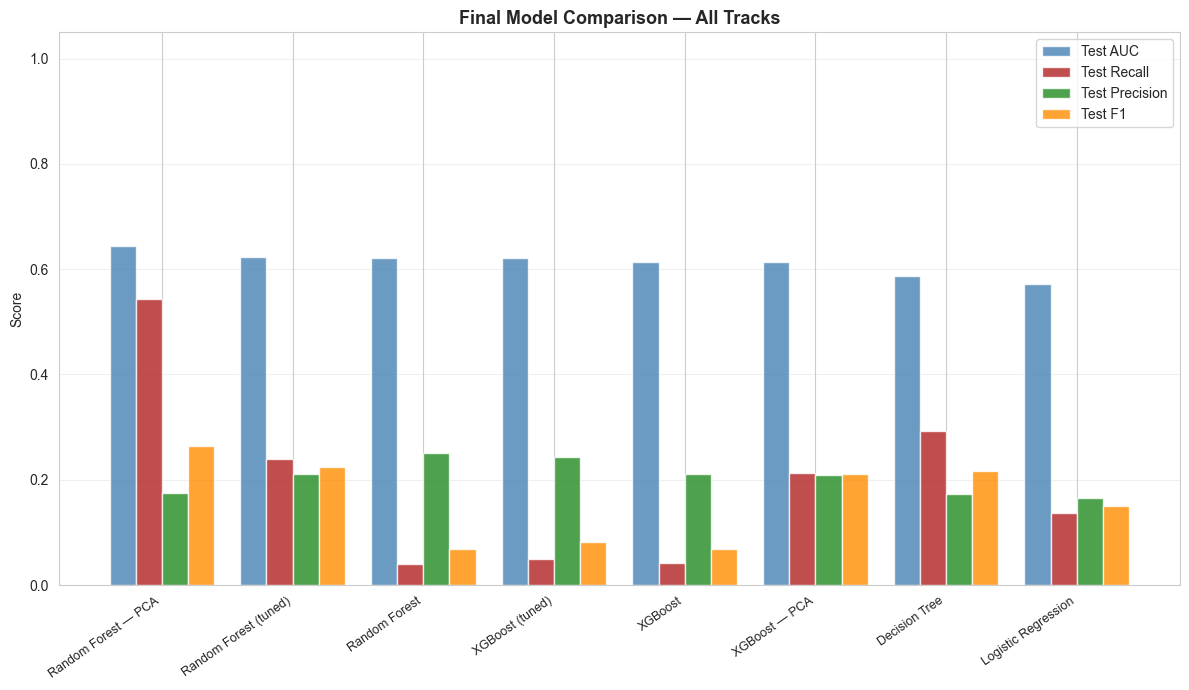


✓ Best model saved to: /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/best_model_random_forest_pca.joblib
✓ Model metadata saved to: models/best_model_metadata.json

✓ Feature Engineering → Modeling pipeline complete.
  Ready for: deployment, A/B testing, and ongoing monitoring.


In [10]:
# ── Consolidated results table (already computed in Section 6) ─────────────────
print("=" * 70)
print("FINAL MODEL COMPARISON (all tracks)")
print("=" * 70)
print(all_results.round(4).to_string())
print(f"\n✓ Best model by AUC: {all_results['Test AUC'].idxmax()}")
print(f"✓ Best model by Recall: {all_results['Test Recall'].idxmax()}")

# ── Final bar chart ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
x = range(len(all_results))
width = 0.2
metrics_to_plot = ["Test AUC", "Test Recall", "Test Precision", "Test F1"]
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]
colors_bar = ["steelblue", "firebrick", "forestgreen", "darkorange"]

for offset, metric, c in zip(offsets, metrics_to_plot, colors_bar):
    ax.bar([xi + offset for xi in x], all_results[metric], width=width, label=metric, color=c, alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(all_results.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Final Model Comparison — All Tracks", fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Save best model ───────────────────────────────────────────────────────────
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

# Determine artifact name from best model
name_base = best_name.lower().replace(" ", "_").replace("—", "").replace("__", "_").strip("_")
model_path = models_dir / f"best_model_{name_base}.joblib"
joblib.dump(best_model, model_path)
print(f"\n✓ Best model saved to: {model_path}")

# Save threshold + metadata
threshold_meta = {
    "model": best_name,
    "optimal_threshold": float(optimal_threshold),
    "test_auc": float(all_results.loc[best_name, "Test AUC"]),
    "test_recall_at_threshold": float(recall_score(y_test, y_pred_final)),
    "test_precision_at_threshold": float(precision_score(y_test, y_pred_final)),
    "test_f1_at_threshold": float(f1_score(y_test, y_pred_final)),
    "feature_track": "PCA (44 components)" if is_pca_best else "MI-selected (117 features), unscaled",
    "training_data": "SMOTE-balanced (141,980 records)",
}
import json as _json
(models_dir / "best_model_metadata.json").write_text(_json.dumps(threshold_meta, indent=2))
print("✓ Model metadata saved to: models/best_model_metadata.json")
print(f"\n✓ Feature Engineering → Modeling pipeline complete.")
print(f"  Ready for: deployment, A/B testing, and ongoing monitoring.")

## 9. Deployment-Ready Pipeline

Notebook 02 saved the transformed **data CSVs** and the fitted preprocessing objects (StandardScaler, PCA transformer, feature-selection list). For production inference, a new patient encounter must pass through the same preprocessing chain before the model can score it.

This section builds and saves a deployment-ready `sklearn.Pipeline` that adapts to whichever model won:

- **If PCA model won**: Selects the 117 MI-selected features → scales continuous features → applies PCA → predicts with the tuned model and the clinically optimised threshold.
- **If non-PCA model won**: Selects the 117 MI-selected features → predicts directly (tree-based models don't need scaling).

Feature engineering (ICD-9 mapping, utilisation flags, one-hot encoding) is handled upstream by the `src/` preprocessing modules.

Additionally, the **StandardScaler**, **PCA transformer**, and **feature-selection column list** are saved as standalone artifacts so that alternative pipelines or retraining workflows can reuse them.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# ── 1. Save MI-selected feature list ─────────────────────────────────────────
selected_features = list(X_test_sel.columns)
features_path = models_dir / "selected_features.json"
import json as _json
_json.loads  # ensure import
with open(features_path, "w") as f:
    _json.dump(selected_features, f, indent=2)
print(f"✓ Feature list saved ({len(selected_features)} features): {features_path}")

# ── 2. Save StandardScaler and PCA transformer ───────────────────────────────
from sklearn.preprocessing import StandardScaler

continuous_cols = scaler_artifact["continuous_cols"]
scaler = scaler_artifact["scaler"]

scaler_path = models_dir / "standard_scaler.joblib"
joblib.dump(scaler_artifact, scaler_path)
print(f"✓ StandardScaler saved ({len(continuous_cols)} continuous features): {scaler_path}")

if is_pca_best:
    pca_path = models_dir / "pca_transformer.joblib"
    joblib.dump(pca_transformer, pca_path)
    print(f"✓ PCA transformer saved ({pca_transformer.n_components_} components): {pca_path}")

# ── 3. Custom transformers ────────────────────────────────────────────────────
class FeatureSelector(BaseEstimator, TransformerMixin):
    """Select a fixed set of columns by name."""
    def __init__(self, feature_names):
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.feature_names]

class ColumnScaler(BaseEstimator, TransformerMixin):
    """Apply a pre-fitted StandardScaler to specific continuous columns."""
    def __init__(self, scaler, continuous_cols):
        self.scaler = scaler
        self.continuous_cols = continuous_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out[self.continuous_cols] = self.scaler.transform(X[self.continuous_cols])
        return X_out

class DataFrameToArray(BaseEstimator, TransformerMixin):
    """Convert DataFrame to numpy array.

    Column names are sanitised in this notebook (brackets → underscores for
    XGBoost compatibility) but the PCA transformer was fit with the original
    names.  Stripping column names avoids the feature-name mismatch.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.values if hasattr(X, "values") else np.asarray(X)

# ── 4. Build deployment pipeline ──────────────────────────────────────────────
# Some continuous columns may not survive MI feature selection, so filter
# and build a scaler that matches only the retained columns.
pipeline_cont_cols = [c for c in continuous_cols if c in selected_features]
cont_idx = [continuous_cols.index(c) for c in pipeline_cont_cols]

deploy_scaler = StandardScaler()
deploy_scaler.mean_ = scaler.mean_[cont_idx]
deploy_scaler.scale_ = scaler.scale_[cont_idx]
deploy_scaler.var_ = scaler.var_[cont_idx]
deploy_scaler.n_features_in_ = len(pipeline_cont_cols)

dropped = set(continuous_cols) - set(pipeline_cont_cols)
if dropped:
    print(f"  ℹ {len(dropped)} continuous columns excluded from pipeline scaler (not in MI-selected features): {sorted(dropped)}")

if is_pca_best:
    deployment_pipeline = Pipeline([
        ("feature_selector", FeatureSelector(selected_features)),
        ("scaler", ColumnScaler(deploy_scaler, pipeline_cont_cols)),
        ("to_array", DataFrameToArray()),
        ("pca", pca_transformer),
        ("model", best_model),
    ])
    print("✓ Deployment pipeline: FeatureSelector → Scaler → Array → PCA → Model")
else:
    deployment_pipeline = Pipeline([
        ("feature_selector", FeatureSelector(selected_features)),
        ("model", best_model),
    ])
    print("✓ Deployment pipeline: FeatureSelector → Model")

# Quick sanity check: predictions should match direct model output
pipe_probs = deployment_pipeline.predict_proba(X_test_sel)[:, 1]
direct_probs = best_model.predict_proba(best_X_te)[:, 1]
assert np.allclose(pipe_probs, direct_probs), "Pipeline output mismatch!"
print("✓ Pipeline sanity check passed — outputs match direct model")

# ── 5. Save pipeline + threshold ──────────────────────────────────────────────
pipeline_path = models_dir / "deployment_pipeline.joblib"
joblib.dump({
    "pipeline": deployment_pipeline,
    "optimal_threshold": float(optimal_threshold),
    "features_expected": selected_features,
    "model_name": best_name,
    "is_pca": is_pca_best,
}, pipeline_path)
print(f"✓ Deployment pipeline saved: {pipeline_path}")

# ── 6. Demonstrate inference on a single sample ──────────────────────────────
sample = X_test_sel.iloc[[0]]
prob = deployment_pipeline.predict_proba(sample)[:, 1][0]
prediction = int(prob >= optimal_threshold)
label = "READMIT (high risk)" if prediction == 1 else "NO READMIT (low risk)"
print(f"\n--- Example inference ---")
print(f"  Patient readmission probability : {prob:.4f}")
print(f"  Threshold                       : {optimal_threshold:.4f}")
print(f"  Prediction                      : {label}")

# ── Summary of saved artifacts ────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("SAVED ARTIFACTS (models/ directory)")
print(f"{'=' * 60}")
artifacts = [
    (f"best_model_{name_base}.joblib", f"Best model: {best_name} (standalone)"),
    ("best_model_metadata.json",       "Model metadata & threshold"),
    ("selected_features.json",         f"MI-selected feature names ({len(selected_features)})"),
    ("standard_scaler.joblib",         f"StandardScaler + continuous column list ({len(continuous_cols)} cols)"),
]
if is_pca_best:
    artifacts.append(("pca_transformer.joblib", f"PCA transformer ({pca_transformer.n_components_} components)"))
artifacts.append(("deployment_pipeline.joblib", f"Complete inference pipeline + threshold"))

for fname, desc in artifacts:
    exists = "✓" if (models_dir / fname).exists() else "✗"
    print(f"  {exists} {fname:40s} {desc}")

print(f"\n✓ Deployment pipeline ready.")
print(f"  Usage: pipeline.predict_proba(df_encoded)[:, 1] >= threshold")

✓ Feature list saved (117 features): /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/selected_features.json
✓ StandardScaler saved (11 continuous features): /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/standard_scaler.joblib
✓ PCA transformer saved (44 components): /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/pca_transformer.joblib
  ℹ 2 continuous columns excluded from pipeline scaler (not in MI-selected features): ['log_outpatient', 'num_medications']
✓ Deployment pipeline: FeatureSelector → Scaler → Array → PCA → Model
✓ Pipeline sanity check passed — outputs match direct model
✓ Deployment pipeline saved: /Users/josefernandogonzales/Desktop/Solvin/Learning/Emeritus_AI/diabetic-readmission-prediction/models/deployment_pipeline.joblib

--- Example inference ---
  Patient readmission probability : 0.4474
  Threshold 